# TB Chest X-ray Classifier — Walkthrough

This notebook drives the pipeline in `src/` (data processing, training, evaluation). Run from the project root.

## 1. Load metadata and class balance

In [1]:
import os
import sys

ROOT = os.getcwd()
if not os.path.isfile(os.path.join(ROOT, "config.yaml")):
    ROOT = os.path.dirname(ROOT)
os.chdir(ROOT)
sys.path.insert(0, os.path.join(ROOT, "src"))

import pandas as pd
import matplotlib.pyplot as plt
import torch

from data import load_config, load_metadata, validate_files, get_dataloaders
from model import build_model
from train import train
from evaluate import evaluate_checkpoint, format_report

cfg = load_config("config.yaml")
df = load_metadata(cfg["data"]["root"])

In [2]:
counts = df["label"].value_counts()
counts

label
Normal          200
Tuberculosis    200
Name: count, dtype: int64

In [3]:
imbalance = counts["Tuberculosis"] / counts["Normal"]
print(f"Imbalance ratio (TB/Normal): {imbalance:.3f}")

Imbalance ratio (TB/Normal): 1.000


## 2. Sample images per class

Visual sanity check that each class actually holds readable chest X-rays.

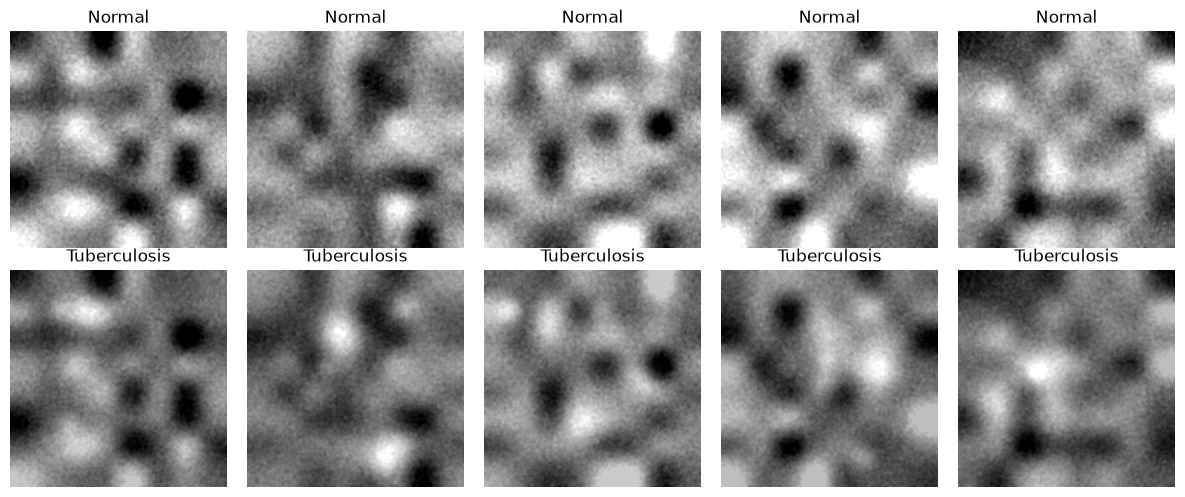

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for row, label in enumerate(["Normal", "Tuberculosis"]):
    for col, path in enumerate(df[df["label"] == label]["filename"].head(5)):
        img = plt.imread(os.path.join(cfg["data"]["root"], path))
        axes[row, col].imshow(img, cmap="gray")
        axes[row, col].set_title(label)
        axes[row, col].axis("off")
plt.tight_layout()
plt.show()

## 3. Data cleaning

Verify every row in `metadata.csv` maps to an actual file on disk.

In [5]:
clean, missing, corrupt = validate_files(df, cfg["data"]["root"])
print(f"Kept {len(clean)}/{len(df)} rows after cleaning")

Kept 400/400 rows after cleaning


## 4. Preprocessing and split

Images are decoded and enhanced with **OpenCV** (`src/preprocessing.py`):
grayscale load, CLAHE local-contrast boost, then resize to a fixed square.
`get_dataloaders()` builds the split loaders; check sizes and class ratios.

In [6]:
data = get_dataloaders(cfg)

for name in ("train", "val", "test"):
    split_df = getattr(data, f"{name}_df")
    print(f"{name}: {len(split_df)} images")

train: 279 images
val: 61 images
test: 60 images


In [7]:
for name in ("train", "val", "test"):
    split_df = getattr(data, f"{name}_df")
    counts = split_df["label"].value_counts()
    print(
        f"{name}: {dict(counts)}  "
        f"ratio TB/Normal = {counts['Tuberculosis'] / counts['Normal']:.3f}"
    )

train: {'Tuberculosis': np.int64(140), 'Normal': np.int64(139)}  ratio TB/Normal = 1.007
val: {'Normal': np.int64(31), 'Tuberculosis': np.int64(30)}  ratio TB/Normal = 0.968
test: {'Tuberculosis': np.int64(30), 'Normal': np.int64(30)}  ratio TB/Normal = 1.000


## 5. Model design

A tiny CNN (3 conv blocks + global average pooling, ~16k params) is used:
with only 400 grayscale images a deep network overfits immediately, while
this one trains on CPU in seconds.

In [8]:
model = build_model(cfg)
print(model)
n_params = sum(p.numel() for p in model.parameters())
print(f"\nParameters: {n_params:,}")

TBCNN(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU()
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU()
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (2): Sequential(
      (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU()
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
  )
  (head): Sequential(
    (0): Ada

## 6. Training

Train the model (class-weighted loss, early stopping on val loss, best checkpoint saved to `checkpoints/`, per-epoch metrics to `experiments/run.csv`).

In [9]:
model, data = train(cfg)

epoch   0  train_loss 0.6943  val_loss 0.6930  val_pr_auc 0.6660


epoch   1  train_loss 0.6544  val_loss 0.6917  val_pr_auc 0.7352


epoch   2  train_loss 0.6369  val_loss 0.6897  val_pr_auc 0.7581


epoch   3  train_loss 0.6263  val_loss 0.6880  val_pr_auc 0.7851


epoch   4  train_loss 0.6201  val_loss 0.6845  val_pr_auc 0.7785


...

epoch  32  train_loss 0.2174  val_loss 2.2164  val_pr_auc 0.9684


epoch  33  train_loss 0.2449  val_loss 1.8726  val_pr_auc 0.9701


epoch  34  train_loss 0.2925  val_loss 0.2874  val_pr_auc 0.9561


epoch  35  train_loss 0.3213  val_loss 1.9758  val_pr_auc 0.9372


epoch  36  train_loss 0.2616  val_loss 4.3311  val_pr_auc 0.9210
Early stopping at epoch 36


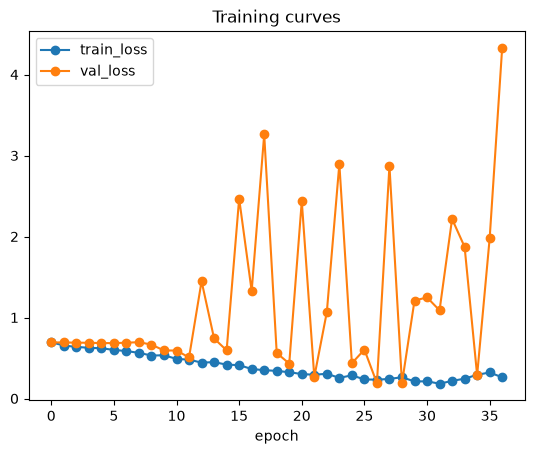

In [10]:
run = pd.read_csv("experiments/run.csv")
run.plot(x="epoch", y=["train_loss", "val_loss"], marker="o")
plt.title("Training curves")
plt.show()

## 7. Evaluation

Metrics on train/val/test side by side so any overfitting gap is visible.

In [11]:
results = evaluate_checkpoint(cfg, "checkpoints/best.pt")
format_report(results)

,train,val,test
precision (Normal),0.8023,0.8378,0.7500
recall (Normal),0.9928,1.0000,1.0000
f1 (Normal),0.8875,0.9118,0.8571
precision (Tuberculosis),0.9907,1.0000,1.0000
recall (Tuberculosis),0.7571,0.8000,0.6667
f1 (Tuberculosis),0.8583,0.8889,0.8000
accuracy,0.8746,0.9016,0.8333
roc_auc,0.9792,0.9946,0.9611
pr_auc,0.9816,0.9942,0.9670


In [12]:
for split, m in results.items():
    cm = pd.DataFrame(
        m["confusion"],
        index=["True Normal", "True TB"],
        columns=["Pred Normal", "Pred TB"],
    )
    print(f"--- {split} ---")
    print(cm)
    print()

--- train ---
             Pred Normal  Pred TB
True Normal          138        1
True TB               34      106

--- val ---
             Pred Normal  Pred TB
True Normal           31        0
True TB                6       24

--- test ---
             Pred Normal  Pred TB
True Normal           30        0
True TB               10       20



## 8. Sample predictions

A few test images with predicted vs actual label.

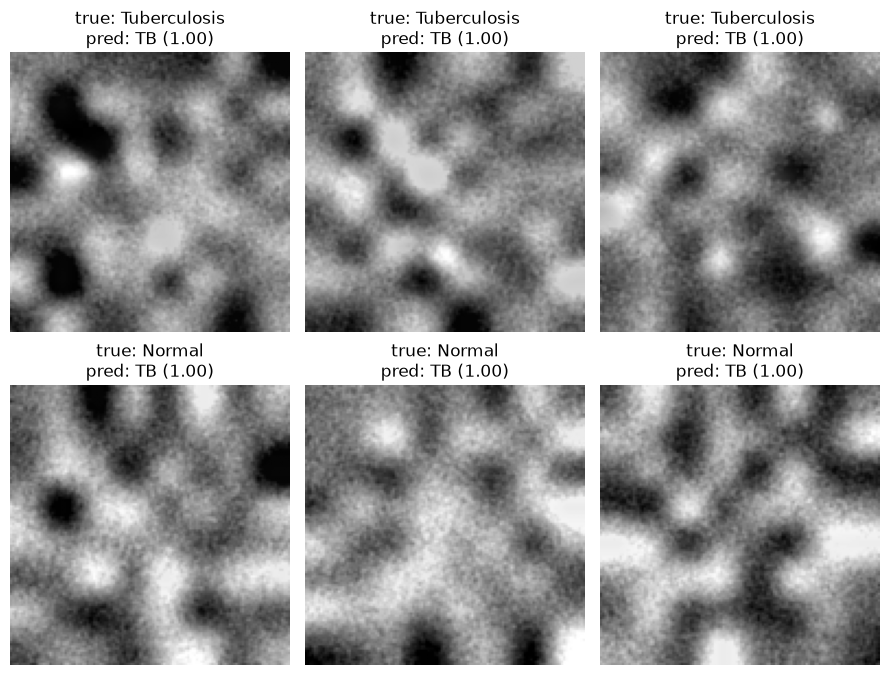

In [13]:
ds = data.test_loader.dataset
tb = [i for i in range(len(ds)) if ds.df["label_int"].iloc[i] == 1][:3]
normal = [i for i in range(len(ds)) if ds.df["label_int"].iloc[i] == 0][:3]

model.eval()
device = next(model.parameters()).device
fig, axes = plt.subplots(2, 3, figsize=(9, 7))
for ax, i in zip(axes.flat, tb + normal):
    x, _ = ds[i]
    with torch.no_grad():
        p = torch.softmax(model(x.unsqueeze(0).to(device)), dim=1)[0, 1].item()
    ax.imshow(x.squeeze(), cmap="gray")
    ax.set_title(
        f"true: {ds.df.iloc[i]['label']}\n"
        f"pred: {'TB' if p >= 0.5 else 'Normal'} ({p:.2f})"
    )
    ax.axis("off")
plt.tight_layout()
plt.show()